In [1]:
import os, zipfile
import numpy as np
import tensorflow as tf
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


In [2]:
from google.colab import drive
drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Extracted:", os.listdir(BASE))


Mounted at /content/drive
Extracted: ['New hand pd Dataset', 'Hand Pd']


In [3]:
HANDPD_ROOT = os.path.join(BASE, "Hand Pd")
NEWHANDPD_ROOT = os.path.join(BASE, "New hand pd Dataset")

def collect_from_handpd():
    paths = []
    labels = []

    for sub in ["Spiral_HandPD", "Meander_HandPD"]:
        sub_root = os.path.join(HANDPD_ROOT, sub)

        for cls in os.listdir(sub_root):
            cls_path = os.path.join(sub_root, cls)
            if not os.path.isdir(cls_path):
                continue

            cls_lower = cls.lower()

            if cls_lower == "healthy":
                lab = 0
            elif cls_lower == "parkinson":
                lab = 1
            else:
                continue

            for root, dirs, files in os.walk(cls_path):
                for f in files:
                    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                        paths.append(os.path.join(root, f))
                        labels.append(lab)

    return paths, labels


def collect_from_newhandpd():
    paths = []
    labels = []

    healthy_root = os.path.join(NEWHANDPD_ROOT, "Healthy")
    park_root = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

    for root, dirs, files in os.walk(healthy_root):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                paths.append(os.path.join(root, f))
                labels.append(0)

    for root, dirs, files in os.walk(park_root):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                paths.append(os.path.join(root, f))
                labels.append(1)

    return paths, labels


paths1, labels1 = collect_from_handpd()
paths2, labels2 = collect_from_newhandpd()

image_paths = paths1 + paths2
labels = labels1 + labels2

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))
print("Healthy:", np.sum(labels==0))
print("Parkinson:", np.sum(labels==1))


Total images: 1320
Healthy: 449
Parkinson: 871


In [4]:
train_paths, test_paths, y_train, y_test = train_test_split(
    image_paths, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    test_paths, y_test,
    test_size=0.50,
    random_state=42,
    stratify=y_test
)

print("Train:", len(train_paths), np.bincount(y_train))
print("Val  :", len(val_paths), np.bincount(y_val))
print("Test :", len(test_paths), np.bincount(y_test))


Train: 1056 [359 697]
Val  : 132 [45 87]
Test : 132 [45 87]


In [5]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)


Class weights: {0: 1.4707520891364902, 1: 0.757532281205165}


In [6]:
IMG_SIZE = 224

def preprocess_cv2(path):
    path = path.numpy().decode()

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        # return blank safe image
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # light denoise (good for sketches)
    img = cv2.GaussianBlur(img, (3,3), 0)

    # CLAHE to enhance strokes
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # normalize ONCE
    img = img.astype(np.float32) / 255.0

    # keep as (224,224,1)
    img = np.expand_dims(img, axis=-1)

    return img


def tf_preprocess(path, label):
    img = tf.py_function(preprocess_cv2, [path], Tout=tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    label = tf.cast(label, tf.float32)
    return img, label


In [8]:
BATCH_SIZE = 16

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(1500)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, y_train, training=True)
val_ds   = make_ds(val_paths, y_val, training=False)
test_ds  = make_ds(test_paths, y_test, training=False)

print("Datasets ready ")


Datasets ready 


Batch shape: (16, 224, 224, 1)
Min/Max: 0.011764706 1.0
Labels: [1. 1. 1. 0. 0. 0. 1. 1. 1. 1.]


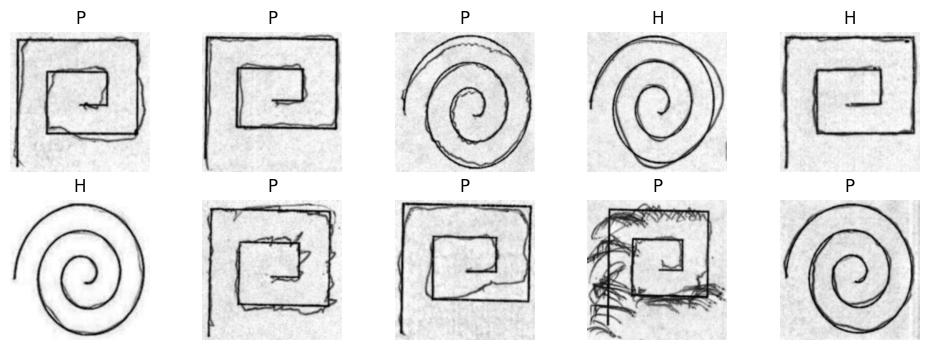

In [9]:
import matplotlib.pyplot as plt

for imgs, labs in train_ds.take(1):
    print("Batch shape:", imgs.shape)
    print("Min/Max:", tf.reduce_min(imgs).numpy(), tf.reduce_max(imgs).numpy())
    print("Labels:", labs[:10].numpy())

    plt.figure(figsize=(12,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        plt.title("P" if labs[i]==1 else "H")
        plt.axis("off")
    plt.show()


In [10]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmentation")


In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # 196
EMBED_DIM = 256

class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=256, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)  # (B, 14, 14, embed_dim)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])  # (B, 196, embed_dim)
        return x


class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(1, self.num_patches + 1, self.embed_dim),  # +1 for CLS
            initializer="random_normal",
            trainable=True
        )

        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]

        cls_tokens = tf.repeat(self.cls_token, repeats=batch_size, axis=0)  # (B,1,D)
        x = tf.concat([cls_tokens, x], axis=1)  # (B,197,D)

        x = x + self.pos_embed
        return x


In [12]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation=tf.nn.gelu),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        # Attention
        x1 = self.norm1(x)
        attn_out = self.attn(x1, x1, training=training)
        x = x + self.drop1(attn_out, training=training)

        # MLP
        x2 = self.norm2(x)
        x = x + self.mlp(x2, training=training)

        return x


In [15]:
def build_custom_vit(
    image_size=224,
    patch_size=16,
    embed_dim=256,
    num_blocks=6,
    num_heads=8,
    mlp_dim=512,
    dropout=0.1
):
    inputs = layers.Input(shape=(image_size, image_size, 1))

    # Augmentation (use the one you already defined)
    x = data_augmentation(inputs)

    # Patch embedding
    x = PatchEmbedding(patch_size=patch_size, embed_dim=embed_dim, name="patch_embed")(x)

    # Add CLS + position embedding
    x = AddPositionEmbedding(num_patches=NUM_PATCHES, embed_dim=embed_dim, name="pos_embed")(x)

    x = layers.Dropout(dropout)(x)

    # Transformer blocks
    for i in range(num_blocks):
        x = TransformerEncoder(
            embed_dim=embed_dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout,
            name=f"encoder_{i}"
        )(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Take CLS token output
    cls_out = x[:, 0]  # (B, embed_dim)

    # Classification head
    cls_out = layers.Dense(256, activation="relu")(cls_out)
    cls_out = layers.Dr_


In [17]:
vit_model = build_custom_vit()
vit_model.summary()


AttributeError: module 'keras._tf_keras.keras.layers' has no attribute 'Dr_'

In [16]:
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss=loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


NameError: name 'vit_model' is not defined